In [2]:
import numpy as np, pandas as pd, glob, os, time
from sklearn.model_selection import GroupShuffleSplit

BASE = "/kaggle/input/competitions/shopee-product-matching"
df = pd.read_csv(f"{BASE}/train.csv")
SEED = 42
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_i, rest_i = next(gss.split(df, groups=df.label_group))
train = df.iloc[train_i].reset_index(drop=True)
rest = df.iloc[rest_i]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_i, test_i = next(gss2.split(rest, groups=rest.label_group))
val = rest.iloc[val_i].reset_index(drop=True)
test = rest.iloc[test_i].reset_index(drop=True)
for name, d in [("train", train), ("val", val), ("test", test)]:
    print(name, len(d), d.label_group.nunique())

def set_f1(pred_sets, labels):
    labels = np.asarray(labels)
    sizes = pd.Series(labels).map(pd.Series(labels).value_counts()).values
    f1 = np.empty(len(labels))
    for i, P in enumerate(pred_sets):
        P = np.asarray(P)
        inter = (labels[P] == labels[i]).sum()
        f1[i] = 2 * inter / (len(P) + sizes[i])
    return f1.mean()

def prec_rec(pred_sets, labels):
    labels = np.asarray(labels)
    sizes = pd.Series(labels).map(pd.Series(labels).value_counts()).values
    ps, rs = [], []
    for i, P in enumerate(pred_sets):
        P = np.asarray(P)
        inter = (labels[P] == labels[i]).sum()
        ps.append(inter / len(P)); rs.append(inter / sizes[i])
    return np.mean(ps), np.mean(rs)

def predict(S, thr):
    return [np.where(S[i] >= thr)[0] for i in range(len(S))]

def sweep(S, lab, thresholds):
    res = [(round(float(t), 3), float(set_f1(predict(S, t), lab))) for t in thresholds]
    return res, max(res, key=lambda r: r[1])

lab = val.label_group.values
g = pd.Series(lab).map(pd.Series(lab).value_counts()).values
print("val floor:", round((2 / (g + 1)).mean(), 4))   # expect 0.4629

train 23724 7709
val 5115 1652
test 5411 1653
val floor: 0.4629


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)                     # must say cuda; stop if it says cpu

weights = models.ResNet50_Weights.IMAGENET1K_V2
model = models.resnet50(weights=weights)
model.fc = torch.nn.Identity()
model = model.to(device).eval()
preprocess = weights.transforms()

class Imgs(Dataset):
    def __init__(self, names): self.names = list(names)
    def __len__(self): return len(self.names)
    def __getitem__(self, i):
        img = Image.open(f"{BASE}/train_images/{self.names[i]}").convert("RGB")
        return preprocess(img)

def embed(names, batch_size=64):
    dl = DataLoader(Imgs(names), batch_size=batch_size, num_workers=2)
    out = []
    with torch.no_grad():
        for x in dl:
            f = model(x.to(device))
            out.append(torch.nn.functional.normalize(f, dim=1).cpu().numpy())
    return np.concatenate(out)

t0 = time.time()
E_val = embed(val.image)
E_test = embed(test.image)
print(E_val.shape, E_test.shape, round(time.time() - t0), "s")
np.save("/kaggle/working/resnet50_val.npy", E_val)
np.save("/kaggle/working/resnet50_test.npy", E_test)

S_img = E_val @ E_val.T
np.fill_diagonal(S_img, 1.0)
print("check: image val F1 at 0.79 (Part C: 0.6917):",
      round(set_f1(predict(S_img, 0.79), lab), 4))

device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 143MB/s] 


(5115, 2048) (5411, 2048) 125 s
check: image val F1 at 0.79 (Part C: 0.6917): 0.6917


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vec = TfidfVectorizer(lowercase=True)
vec.fit(val.title)                       # as in Part B: fitted on the pool, no labels
S_txt = cosine_similarity(vec.transform(val.title))
np.fill_diagonal(S_txt, 1.0)
print("check: text val F1 at 0.43 (Part B: 0.7770):",
      round(set_f1(predict(S_txt, 0.43), lab), 4))

for name, Sx in [("text", S_txt), ("image", S_img)]:
    print(name, "min/mean/max:", Sx.min().round(3), Sx.mean().round(3), Sx.max().round(3))

check: text val F1 at 0.43 (Part B: 0.7770): 0.777
text min/mean/max: 0.0 0.004 1.0
image min/mean/max: 0.006 0.234 1.0


In [5]:
S_fuse = 0.5 * S_txt + 0.5 * S_img
res_b, best_b = sweep(S_fuse, lab, np.arange(0.15, 0.96, 0.025))
for r in res_b: print(r)
print("fusion baseline (w=0.5) best:", best_b)

bt = best_b[0]
res_bf, best_bf = sweep(S_fuse, lab, np.arange(bt - 0.025, bt + 0.0251, 0.005))
print("refined:", best_bf)
p, r = prec_rec(predict(S_fuse, best_bf[0]), lab)
print("precision", round(p, 3), "recall", round(r, 3))

(0.15, 0.016439457262184407)
(0.175, 0.029843651246859615)
(0.2, 0.0536352909115053)
(0.225, 0.09383454905508407)
(0.25, 0.15607550304332857)
(0.275, 0.23998342126280583)
(0.3, 0.3410947584192181)
(0.325, 0.44776750028713225)
(0.35, 0.553287218314892)
(0.375, 0.6489661412222834)
(0.4, 0.7270644276903302)
(0.425, 0.7882859506988279)
(0.45, 0.8254457575757016)
(0.475, 0.8427749063396788)
(0.5, 0.8514564164526036)
(0.525, 0.8503746002625672)
(0.55, 0.8412208618151086)
(0.575, 0.8232788573260654)
(0.6, 0.8038745020216711)
(0.625, 0.7820983541358788)
(0.65, 0.7585479160281702)
(0.675, 0.7307711294653606)
(0.7, 0.7025370589958467)
(0.725, 0.6732963011788593)
(0.75, 0.6445379594994454)
(0.775, 0.6171541629105143)
(0.8, 0.5896089481240909)
(0.825, 0.5676341343777107)
(0.85, 0.5466188298891034)
(0.875, 0.5238503074822328)
(0.9, 0.5061203259483573)
(0.925, 0.4913038758558807)
(0.95, 0.4783592720778798)
fusion baseline (w=0.5) best: (0.5, 0.8514564164526036)
refined: (0.505, 0.8521603572216159)
p

 w_text  threshold  val F1  precision  recall
    0.0       0.80  0.6898      0.948   0.615
    0.2       0.65  0.7760      0.931   0.742
    0.4       0.55  0.8463      0.924   0.842
    0.5       0.50  0.8515      0.895   0.874
    0.6       0.50  0.8432      0.913   0.845
    0.8       0.45  0.8137      0.882   0.829
    1.0       0.40  0.7763      0.834   0.815
11 s


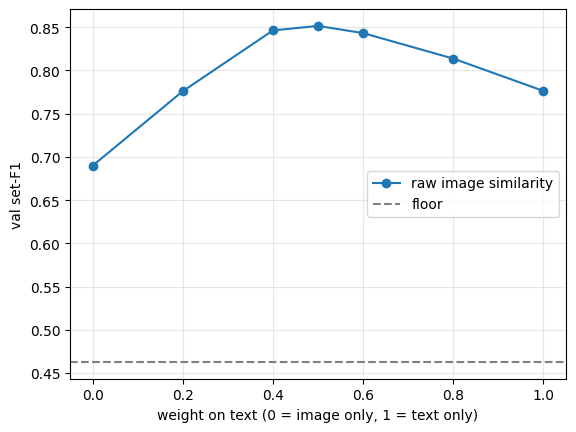

In [6]:
import matplotlib.pyplot as plt

def fuse_sweep(S_a, S_b, weights, thr_grid):
    out = []
    for w in weights:
        Sf = w * S_a + (1 - w) * S_b
        _, (bt, bf) = sweep(Sf, lab, thr_grid)
        p, r = prec_rec(predict(Sf, bt), lab)
        out.append((w, bt, round(bf, 4), round(p, 3), round(r, 3)))
    return pd.DataFrame(out, columns=["w_text", "threshold", "val F1", "precision", "recall"])

weights = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]
t0 = time.time()
df_w = fuse_sweep(S_txt, S_img, weights, np.arange(0.15, 0.96, 0.05))
print(df_w.to_string(index=False))
print(round(time.time() - t0), "s")

os.makedirs("/kaggle/working/results", exist_ok=True)
plt.plot(df_w.w_text, df_w["val F1"], marker="o", label="raw image similarity")
plt.axhline(0.4629, color="gray", linestyle="--", label="floor")
plt.xlabel("weight on text (0 = image only, 1 = text only)")
plt.ylabel("val set-F1"); plt.legend(); plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/results/fusion_weight_sweep_raw.png", dpi=150, bbox_inches="tight")
plt.show()

image centred min/mean/max: -0.307 0.0 1.0
 w_text  threshold  val F1  precision  recall
    0.0       0.75  0.6876      0.962   0.604
    0.2       0.60  0.7532      0.939   0.706
    0.4       0.50  0.8249      0.928   0.808
    0.5       0.45  0.8462      0.900   0.861
    0.6       0.45  0.8475      0.912   0.852
    0.8       0.40  0.8179      0.861   0.855
    1.0       0.40  0.7763      0.834   0.815
10 s


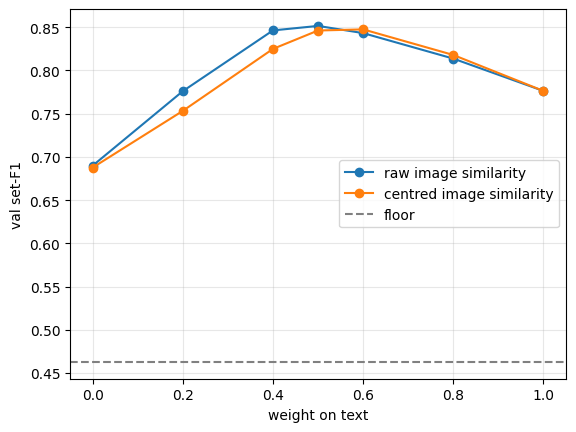

In [7]:
Ec = E_val - E_val.mean(axis=0, keepdims=True)
Ec = Ec / np.linalg.norm(Ec, axis=1, keepdims=True)
S_img_c = Ec @ Ec.T
np.fill_diagonal(S_img_c, 1.0)
print("image centred min/mean/max:", S_img_c.min().round(3), S_img_c.mean().round(3), S_img_c.max().round(3))

t0 = time.time()
df_wc = fuse_sweep(S_txt, S_img_c, weights, np.arange(0.10, 0.96, 0.05))
print(df_wc.to_string(index=False))
print(round(time.time() - t0), "s")

plt.plot(df_w.w_text, df_w["val F1"], marker="o", label="raw image similarity")
plt.plot(df_wc.w_text, df_wc["val F1"], marker="o", label="centred image similarity")
plt.axhline(0.4629, color="gray", linestyle="--", label="floor")
plt.xlabel("weight on text"); plt.ylabel("val set-F1"); plt.legend(); plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/results/fusion_weight_sweep_centred.png", dpi=150, bbox_inches="tight")
plt.show()

## Baseline: score-level fusion

Two similarity matrices over the val pool are combined: text (word TF-IDF,
cosine) and image (ResNet50, cosine). Equal weights, raw scores:
S = 0.5 * S_txt + 0.5 * S_img, then a threshold chosen on val. 

## Experiment 1: weight between text and image

Hypothesis: Changing only the weight w on text:

| w (text) | Threshold | Val F1 | Precision | Recall |
|---|---|---|---|---|
| 0.0 (image only) | 0.80 | 0.6898 | 0.948 | 0.615 |
| 0.2 | 0.65 | 0.7760 | 0.931 | 0.742 |
| 0.4 | 0.55 | 0.8463 | 0.924 | 0.842 |
| **0.5** | **0.50** | **0.8515** | 0.895 | 0.874 |
| 0.6 | 0.50 | 0.8432 | 0.913 | 0.845 |
| 0.8 | 0.45 | 0.8137 | 0.882 | 0.829 |
| 1.0 (text only) | 0.40 | 0.7763 | 0.834 | 0.815 |

Fusion beats both single signals (about +0.075 over text and +0.16 over
image) and raises precision and recall together. The curve is flat between
w = 0.4 and 0.6, so tuning the weight added nothing measurable over equal
weights. The weights are not importances: unrelated image pairs average 0.234
and unrelated text pairs 0.004.

## Experiment 2: centring the image similarity

Hypothesis: the optimum weight for text based matchmaking is 0.5 which gave an F1 score of 0.8515. Subtracting the mean embedding (no labels) so unrelated
image pairs sit near 0 like text pairs:



Centring was worse than raw up to w = 0.5 and 0.004 better at w = 0.6 and
0.8, which is within noise on one split. I kept the raw version as it is
simpler.

In [8]:
def refine_fuse(S_a, S_b, weights, thr_grid):
    rows = []
    for w in weights:
        Sf = w * S_a + (1 - w) * S_b
        _, (bt, bf) = sweep(Sf, lab, thr_grid)
        p, r = prec_rec(predict(Sf, bt), lab)
        rows.append((round(float(w), 2), bt, round(bf, 4), round(p, 3), round(r, 3)))
    return pd.DataFrame(rows, columns=["w_text", "threshold", "val F1", "precision", "recall"])

wts = np.arange(0.30, 0.701, 0.05)
thr_grid = np.arange(0.35, 0.651, 0.01)
df_raw = refine_fuse(S_txt, S_img, wts, thr_grid)
df_cen = refine_fuse(S_txt, S_img_c, wts, thr_grid)
print("RAW image similarity"); print(df_raw.to_string(index=False))
print("CENTRED image similarity"); print(df_cen.to_string(index=False))

best_raw = df_raw.loc[df_raw["val F1"].idxmax()]
best_cen = df_cen.loc[df_cen["val F1"].idxmax()]
use_centred = bool(best_cen["val F1"] > best_raw["val F1"])
sel = best_cen if use_centred else best_raw
print("selected on val:", "centred" if use_centred else "raw", dict(sel))

RAW image similarity
 w_text  threshold  val F1  precision  recall
   0.30       0.59  0.8205      0.924   0.806
   0.35       0.56  0.8365      0.914   0.836
   0.40       0.54  0.8466      0.913   0.852
   0.45       0.52  0.8524      0.905   0.867
   0.50       0.52  0.8521      0.917   0.856
   0.55       0.49  0.8496      0.895   0.871
   0.60       0.48  0.8448      0.893   0.865
   0.65       0.47  0.8387      0.890   0.859
   0.70       0.45  0.8311      0.876   0.862
CENTRED image similarity
 w_text  threshold  val F1  precision  recall
   0.30       0.53  0.7909      0.916   0.774
   0.35       0.52  0.8088      0.929   0.786
   0.40       0.50  0.8249      0.928   0.808
   0.45       0.47  0.8386      0.912   0.841
   0.50       0.46  0.8473      0.912   0.853
   0.55       0.44  0.8494      0.898   0.868
   0.60       0.44  0.8493      0.902   0.863
   0.65       0.43  0.8457      0.896   0.864
   0.70       0.42  0.8382      0.887   0.861
selected on val: raw {'w_text': np

In [9]:
w_f, thr_f = float(sel.w_text), float(sel.threshold)
S_img_sel = S_img_c if use_centred else S_img
S_final = w_f * S_txt + (1 - w_f) * S_img_sel

def best_at(Sx, lo, hi):
    _, (bt, bf) = sweep(Sx, lab, np.arange(lo, hi, 0.01))
    p, r = prec_rec(predict(Sx, bt), lab)
    return bt, round(bf, 4), round(p, 3), round(r, 3)

h = np.array([int(x, 16) for x in val.image_phash], dtype=np.uint64)
B = np.unpackbits(h.view(np.uint8)).reshape(len(h), 64).astype(np.float32)
s = B.sum(1)
S_ph = 1 - (s[:, None] + s[None, :] - 2 * (B @ B.T)) / 64
np.fill_diagonal(S_ph, 1.0)

rows = []
for name, tx, im, ot, Sx, lo, hi in [
        ("A text only", "yes", "no", "no", S_txt, 0.30, 0.60),
        ("B image only (ResNet raw)", "no", "yes", "no", S_img, 0.60, 0.95),
        ("C text + image (final)", "yes", "yes", "no", S_final, 0.35, 0.70)]:
    bt, bf, p, r = best_at(Sx, lo, hi)
    rows.append((name, tx, im, ot, bt, bf, p, r))
for wp in [0.1, 0.2, 0.3]:
    Sx = (1 - wp) * S_final + wp * S_ph
    bt, bf, p, r = best_at(Sx, 0.25, 0.85)
    rows.append((f"D = C + phash (weight {wp})", "yes", "yes", "phash", bt, bf, p, r))

abl = pd.DataFrame(rows, columns=["config", "text", "image", "other", "threshold", "val F1", "precision", "recall"])
print(abl.to_string(index=False))

                    config text image other  threshold  val F1  precision  recall
               A text only  yes    no    no       0.43  0.7770      0.863   0.790
 B image only (ResNet raw)   no   yes    no       0.79  0.6917      0.938   0.626
    C text + image (final)  yes   yes    no       0.52  0.8524      0.905   0.867
D = C + phash (weight 0.1)  yes   yes phash       0.53  0.8525      0.916   0.857
D = C + phash (weight 0.2)  yes   yes phash       0.53  0.8490      0.910   0.857
D = C + phash (weight 0.3)  yes   yes phash       0.53  0.8395      0.897   0.854


In [10]:
lab_t = test.label_group.values
g_t = pd.Series(lab_t).map(pd.Series(lab_t).value_counts()).values

vec_t = TfidfVectorizer(lowercase=True)
vec_t.fit(test.title)
St_txt = cosine_similarity(vec_t.transform(test.title))
np.fill_diagonal(St_txt, 1.0)

St_img = E_test @ E_test.T
np.fill_diagonal(St_img, 1.0)
if use_centred:
    Ec_t = E_test - E_test.mean(axis=0, keepdims=True)
    Ec_t = Ec_t / np.linalg.norm(Ec_t, axis=1, keepdims=True)
    St_img_sel = Ec_t @ Ec_t.T
    np.fill_diagonal(St_img_sel, 1.0)
else:
    St_img_sel = St_img
St_final = w_f * St_txt + (1 - w_f) * St_img_sel

thr_of = dict(zip(abl.config, abl.threshold))
print("test floor:", round((2 / (g_t + 1)).mean(), 4))
for name, Sx in [("A text only", St_txt), ("B image only (ResNet raw)", St_img),
                 ("C text + image (final)", St_final)]:
    f = set_f1(predict(Sx, thr_of[name]), lab_t)
    print(name, "| threshold from val:", thr_of[name], "| test F1:", round(f, 4))

test floor: 0.4401
A text only | threshold from val: 0.43 | test F1: 0.7741
B image only (ResNet raw) | threshold from val: 0.79 | test F1: 0.68
C text + image (final) | threshold from val: 0.52 | test F1: 0.8508


## Final system

- **Representations:** text, word TF-IDF (lowercased, default tokenizer)
  fitted on the titles of the pool being searched, no labels used. Image,
  ResNet50 (ImageNet weights, classifier removed), 2048-d, L2-normalised.
- **Similarity:** cosine similarity for each modality.
- **Fusion:** S = 0.45 * S_text + 0.55 * S_image on raw scores.
- **Matching strategy:** each listing is matched to every listing in the
  same pool with S >= 0.52 (itself included).
- **Hyperparameters:** weight and threshold chosen on val (weight grid 0.30
  to 0.70, threshold grid 0.35 to 0.65 in steps of 0.01).

## Fine search over weight and threshold

 The top is flat: w = 0.45, 0.50
and 0.55 give 0.8524, 0.8521 and 0.8496, so equal weights are within 0.0003
of the best. Raw and centred similarity differ by 0.003, which I treat as a
tie, selecting raw as the simpler option. The weights are not importances,
because the two score scales differ (unrelated pairs average 0.004 for text
and 0.234 for image).

## Ablation

 Both modalities contribute: the fusion is
+0.075 over text and +0.161 over image, and raises precision and recall
together. Adding the perceptual hash changes nothing at weight 0.1 (+0.0001)
and hurts at 0.2 and 0.3.

## Final evaluation on test

| Configuration | Val F1 | Test F1 |
|---|---|---|
| A text only | 0.7770 | 0.7741 |
| B image only | 0.6917 | 0.6800 |
| C text + image (final) | 0.8524 | 0.8508 |

Test floor 0.4401 (val 0.4629). Weights and thresholds were fixed on val and
each configuration was run once on test. The fused system closes about 73% of
the floor-to-perfect gap on both splits.

In [11]:
thr_f = float(sel.threshold)
iu = np.triu_indices(len(lab), k=1)
same = lab[iu[0]] == lab[iu[1]]
sf, st, si = S_final[iu], S_txt[iu], S_img[iu]
pred_f, pred_t, pred_i = sf >= thr_f, st >= 0.43, si >= 0.79

def counts(pred):
    return dict(correct=int((pred & same).sum()), false=int((pred & ~same).sum()),
                missed=int((~pred & same).sum()))
print("fused:", counts(pred_f)); print("text :", counts(pred_t)); print("image:", counts(pred_i))
print("text-only false matches removed by fusion:", int((pred_t & ~same & ~pred_f).sum()))
print("new false matches introduced by fusion  :", int((~pred_t & ~same & pred_f).sum()))
print("true pairs text-only missed, fusion found:", int((~pred_t & same & pred_f).sum()))
print("true pairs text-only found, fusion lost  :", int((pred_t & same & ~pred_f).sum()))

fused: {'correct': 8315, 'false': 1729, 'missed': 2696}
text : {'correct': 7110, 'false': 2551, 'missed': 3901}
image: {'correct': 4516, 'false': 1422, 'missed': 6495}
text-only false matches removed by fusion: 1531
new false matches introduced by fusion  : 709
true pairs text-only missed, fusion found: 1763
true pairs text-only found, fusion lost  : 558


In [12]:
def bucket(mask):
    t_hi, i_hi = pred_t[mask], pred_i[mask]
    return {"both high": int((t_hi & i_hi).sum()), "text high only": int((t_hi & ~i_hi).sum()),
            "image high only": int((~t_hi & i_hi).sum()), "both low": int((~t_hi & ~i_hi).sum())}
fp_mask, fn_mask = pred_f & ~same, ~pred_f & same
print("false matches:", bucket(fp_mask))
print("missed pairs :", bucket(fn_mask))

false matches: {'both high': 120, 'text high only': 900, 'image high only': 256, 'both low': 453}
missed pairs : {'both high': 0, 'text high only': 558, 'image high only': 59, 'both low': 2079}


final_false_matches_top 0 | text 1.00 image 0.99 fused 1.00
   A: Ecolink LED 6 Watt Lampu Bohlam Cool Day Light (Putih)
   B: Ecolink LED 8 Watt Lampu Bohlam Cool Day Light (Putih)
final_false_matches_top 1 | text 0.92 image 1.00 fused 0.96
   A: Extra Bubble Wrap Pengaman Packingan
   B: Tambahan Extra Bubble Wrap Pengaman Packingan
final_false_matches_top 2 | text 1.00 image 0.86 fused 0.92
   A: Ring Light Selfie LED / Lampu selfie Bulat untuk kamera camera hp Flash charm eyes
   B: Ring Light Selfie LED / Lampu Selfie Bulat Untuk Kamera Camera HP Flash Charm Eyes
final_false_matches_top 3 | text 0.84 image 0.99 fused 0.92
   A: EXTRA BUBBLE WRAP UNTUK PACKING
   B: EXTRA Plastik bubble (bubble wrap) untuk packing tambahan


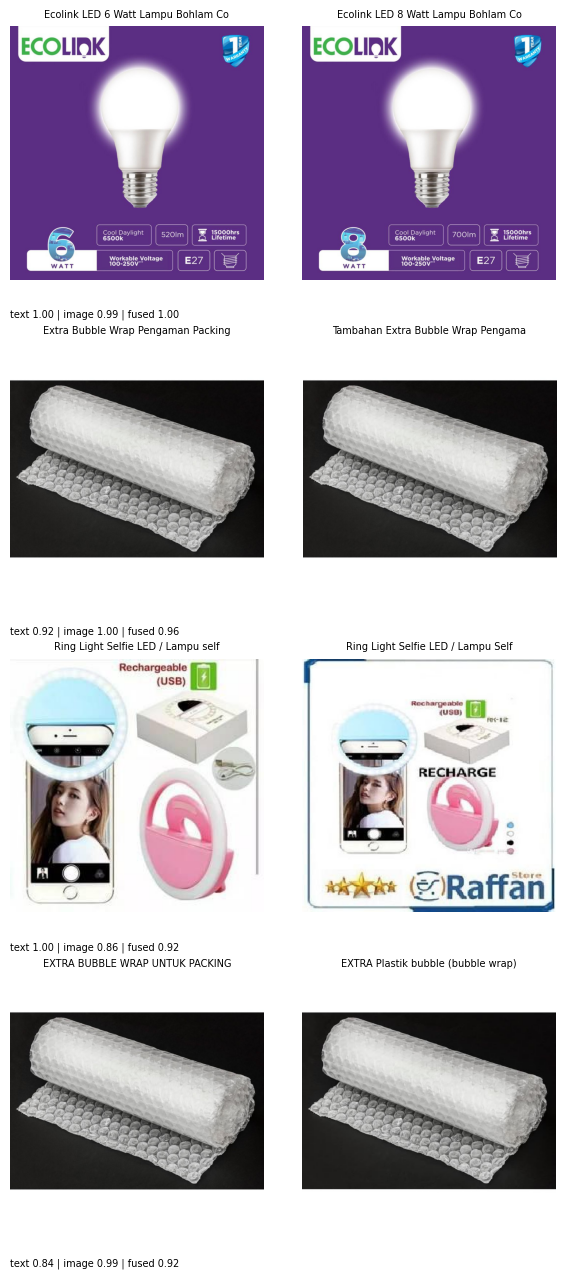

final_missed_random 0 | text 0.34 image 0.58 fused 0.47
   A: Soes GG 2kg
   B: Juara Snack - MURAH - Sus Coklat GG 2kg / Sus Kering
final_missed_random 1 | text 0.41 image 0.38 fused 0.39
   A: [COD]Ready Stock Mini Nano Water Mist Sprayer Facial Steamer Beauty Spray USB Rechargeable SAWU
   B: Nano Spray Perawatan Wajah Mini Portable USB Mist Sprayer Pelembab Wajah Handy Mist Spray - B19008
final_missed_random 2 | text 0.15 image 0.17 fused 0.16
   A: TERMURAH ! Masker Scuba Premium Multifungsi
   B: MASKER HIJAB KAIN OXFROD
final_missed_random 3 | text 0.55 image 0.39 fused 0.47
   A: 100% ORIGINAL BPOM Salsa Dynamatte Lipcream Matte / Lip Cream Matte - Long Lasting Matte grosir
   B: SALSA DYNAMATTE LIP CREAM (MATTE LIP CREAM) 5GR


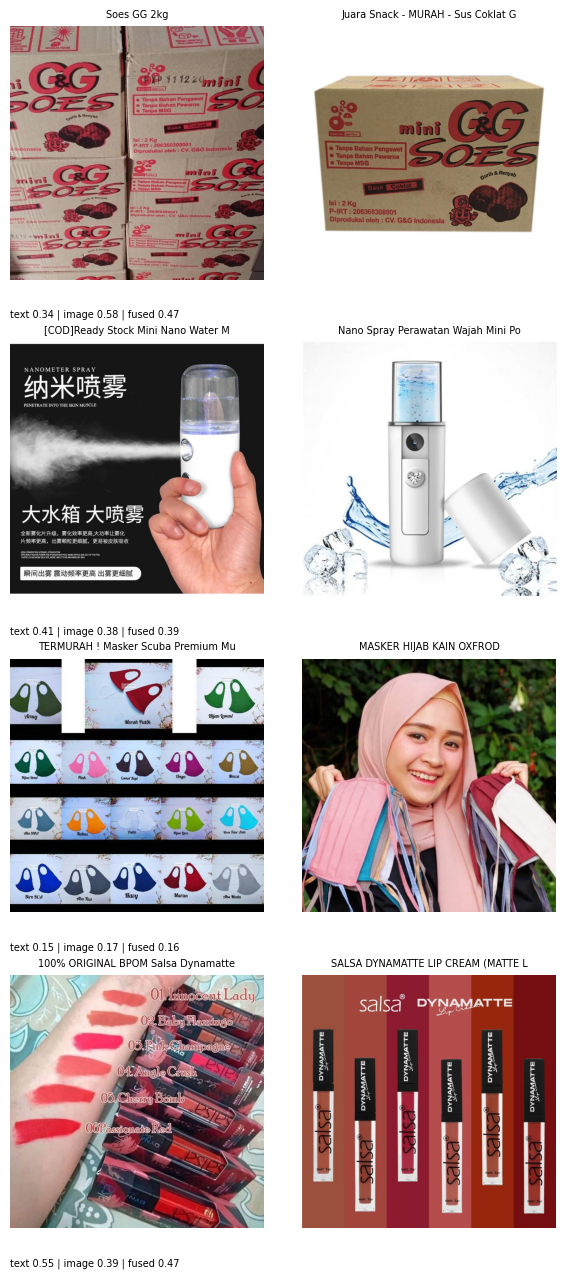

final_missed_conflict 0 | text 0.64 image 0.39 fused 0.50
   A: SALSA Dynamatte Lip Cream Makeup Original BPOM
   B: SALSA DYNAMATTE LIP CREAM (MATTE LIP CREAM) 5GR
final_missed_conflict 1 | text 0.50 image 0.44 fused 0.46
   A: [SALE] Hijab Voal Motif Art Premium Square Lasercut Kerudung Segi empat Motif Jilbab Grosir Murah
   B: Jilbab Potton Doby Segi empat , Hijab Square Printing , Kerudung Premium , Harga Grosir
final_missed_conflict 2 | text 0.56 image 0.40 fused 0.47
   A: (COD) Cream Malam Tabita Malaysia Original
   B: Cream Siang Tabita DS Malaysia
final_missed_conflict 3 | text 0.43 image 0.56 fused 0.51
   A: Gamis
   B: Gamis Katun Motif Polkadot


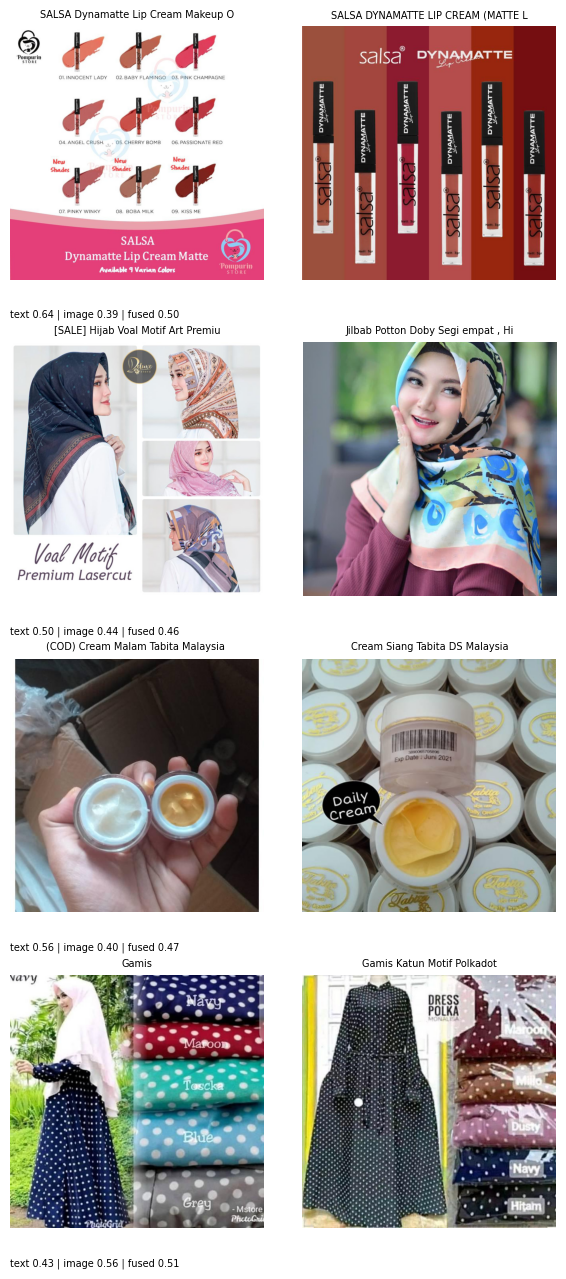

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

def show_pairs2(idx, name):
    fig, axes = plt.subplots(len(idx), 2, figsize=(6, 3.2 * len(idx)))
    axes = np.atleast_2d(axes)
    for r, k in enumerate(idx):
        a, b = iu[0][k], iu[1][k]
        for c, j in enumerate((a, b)):
            axes[r, c].imshow(Image.open(f"{BASE}/train_images/{val.image[j]}"))
            axes[r, c].axis("off"); axes[r, c].set_title(val.title[j][:34], fontsize=7)
        axes[r, 0].text(0, -0.15, f"text {st[k]:.2f} | image {si[k]:.2f} | fused {sf[k]:.2f}",
                        transform=axes[r, 0].transAxes, fontsize=7)
        print(name, r, f"| text {st[k]:.2f} image {si[k]:.2f} fused {sf[k]:.2f}")
        print("   A:", val.title[a]); print("   B:", val.title[b])
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/results/{name}.png", dpi=150, bbox_inches="tight"); plt.show()

rng = np.random.default_rng(5)
fp_idx, fn_idx = np.where(fp_mask)[0], np.where(fn_mask)[0]
show_pairs2(fp_idx[np.argsort(-sf[fp_idx])[:4]], "final_false_matches_top")
show_pairs2(rng.choice(fn_idx, 4, replace=False), "final_missed_random")
conf = fn_idx[pred_t[fn_idx] ^ pred_i[fn_idx]]
show_pairs2(rng.choice(conf, 4, replace=False), "final_missed_conflict")

In [14]:
os.makedirs("/kaggle/working/results", exist_ok=True)
L = ["# Finale results (validation; weights and thresholds chosen on val)", "",
     "## Ablation", "",
     "| config | text | image | other | threshold | val F1 | precision | recall |",
     "|---|---|---|---|---|---|---|---|"]
for _, r in abl.iterrows():
    L.append(f"| {r['config']} | {r['text']} | {r['image']} | {r['other']} | {r['threshold']} | {r['val F1']} | {r['precision']} | {r['recall']} |")
for title, d in [("Fine search, raw image similarity", df_raw), ("Fine search, centred image similarity", df_cen)]:
    L += ["", f"## {title}", "", "| w_text | threshold | val F1 | precision | recall |", "|---|---|---|---|---|"]
    for _, r in d.iterrows():
        L.append(f"| {r['w_text']} | {r['threshold']} | {r['val F1']} | {r['precision']} | {r['recall']} |")
L += ["", "## Test (one run each, val-chosen weight and thresholds)", "",
      "Copied from the notebook output: text only 0.7741, image only 0.6800, text + image 0.8508.",
      "Test floor 0.4401 (val floor 0.4629)."]
open("/kaggle/working/results/experiments.md", "w").write("\n".join(L))
print("\n".join(L[:12]))

# Finale results (validation; weights and thresholds chosen on val)

## Ablation

| config | text | image | other | threshold | val F1 | precision | recall |
|---|---|---|---|---|---|---|---|
| A text only | yes | no | no | 0.43 | 0.777 | 0.863 | 0.79 |
| B image only (ResNet raw) | no | yes | no | 0.79 | 0.6917 | 0.938 | 0.626 |
| C text + image (final) | yes | yes | no | 0.52 | 0.8524 | 0.905 | 0.867 |
| D = C + phash (weight 0.1) | yes | yes | phash | 0.53 | 0.8525 | 0.916 | 0.857 |
| D = C + phash (weight 0.2) | yes | yes | phash | 0.53 | 0.849 | 0.91 | 0.857 |
| D = C + phash (weight 0.3) | yes | yes | phash | 0.53 | 0.8395 | 0.897 | 0.854 |


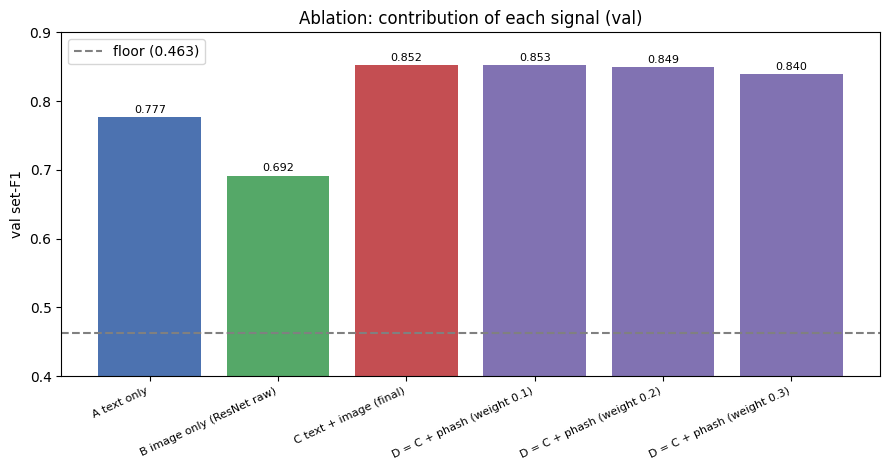

In [15]:
import matplotlib.pyplot as plt
labels = [r["config"] for _, r in abl.iterrows()]
vals = [float(r["val F1"]) for _, r in abl.iterrows()]
plt.figure(figsize=(9, 4.8))
plt.bar(range(len(vals)), vals, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#8172B2", "#8172B2"][:len(vals)])
plt.axhline(0.4629, color="gray", linestyle="--", label="floor (0.463)")
for i, v in enumerate(vals): plt.text(i, v + 0.006, f"{v:.3f}", ha="center", fontsize=8)
plt.xticks(range(len(vals)), labels, rotation=25, ha="right", fontsize=8)
plt.ylabel("val set-F1"); plt.ylim(0.4, 0.9); plt.legend(); plt.title("Ablation: contribution of each signal (val)")
plt.tight_layout()
plt.savefig("/kaggle/working/results/ablation.png", dpi=150, bbox_inches="tight"); plt.show()

## Ablation figure

Val set-F1 for text only (0.777), image only (0.692), text + image (0.852),
and the fusion plus a perceptual-hash term at weights 0.1, 0.2 and 0.3 (0.853,
0.849, 0.840). The dashed line is the floor (0.463). Both modalities
contribute, and the hash adds nothing.

In [16]:
def f1_each(pred_sets, labels):
    labels = np.asarray(labels)
    sizes = pd.Series(labels).map(pd.Series(labels).value_counts()).values
    out = np.empty(len(labels))
    for i, P in enumerate(pred_sets):
        P = np.asarray(P)
        out[i] = 2 * (labels[P] == labels[i]).sum() / (len(P) + sizes[i])
    return out, sizes

systems = {"A text only": predict(S_txt, 0.43), "B image only": predict(S_img, 0.79),
           "C text + image": predict(S_final, 0.52)}
cols = {}
for name, ps in systems.items():
    f, sz = f1_each(ps, lab)
    bucket = pd.cut(pd.Series(sz), bins=[1, 2, 3, 5, 10, 1000], labels=["2", "3", "4-5", "6-10", "11+"])
    cols[name] = pd.Series(f).groupby(bucket, observed=True).mean()
tab = pd.DataFrame(cols)
tab.insert(0, "listings", bucket.value_counts().sort_index())
print("mean per-listing F1 by true group size (val):")
print(tab.round(4).to_string())

mean per-listing F1 by true group size (val):
      listings  A text only  B image only  C text + image
2         2106       0.8034        0.7654          0.8576
3          735       0.7803        0.7063          0.8648
4-5        966       0.7867        0.6911          0.8820
6-10       681       0.7617        0.6384          0.8609
11+        627       0.6860        0.4863          0.7658


## Where fusion helps: F1 by true group size (val)

| True group size | Listings | Text | Image | Text + image |
|---|---|---|---|---|
| 2 | 2,106 | 0.803 | 0.765 | 0.858 |
| 3 | 735 | 0.780 | 0.706 | 0.865 |
| 4-5 | 966 | 0.787 | 0.691 | 0.882 |
| 6-10 | 681 | 0.762 | 0.638 | 0.861 |
| 11+ | 627 | 0.686 | 0.486 | 0.766 |

Fusion is best in every bucket, with the largest gain over text for groups of
6 to 10 (+0.099) and the smallest for pairs (+0.054). Image alone loses the
most as groups grow (0.765 to 0.486), as expected when one product appears in
many different photos. Large groups are the hardest for every system; the 11+
bucket comes from at most about 57 groups, so it is noisy. A single global
threshold is a plausible cause (untested).